In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from pathlib import Path
import sys
import random
import re
import importlib

BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

COMMON_DIR = BASE_DIR / 'synthetic_scenarios'
FRONT_DIR = COMMON_DIR / 'front'

candidate_project_dirs = [
    Path.cwd(),
    COMMON_DIR,
    FRONT_DIR,
]

candidate_project_dirs += [
    p.parent for p in Path('/content/drive').glob(
        '.shortcut-targets-by-id/*/*/synthetic_scenarios/front/shelf_synthetic_common.py'
    )
]

PROJECT_DIR = None
for d in candidate_project_dirs:
    if (d / 'shelf_synthetic_common.py').exists():
        PROJECT_DIR = d
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        'shelf_synthetic_common.py 파일을 찾지 못했습니다. '
        '노트북(.ipynb)과 shelf_synthetic_common.py를 같은 폴더에 두거나, '
        'PROJECT_DIR를 실제 파일 위치로 수정해주세요.'
    )

LABELER_DIR = COMMON_DIR

if not (LABELER_DIR / 'synthetic_label_exporter.py').exists():
    raise FileNotFoundError(
        f'synthetic_label_exporter.py 파일을 찾지 못했습니다: {LABELER_DIR}'
    )

# shelf_synthetic_common.py는 front 폴더에서,
# synthetic_label_exporter.py는 synthetic_scenarios 공통 폴더에서 import
for p in [PROJECT_DIR, LABELER_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print('공통 py 파일 위치:', PROJECT_DIR / 'shelf_synthetic_common.py')
print('라벨 exporter 위치:', LABELER_DIR / 'synthetic_label_exporter.py')
print('BASE_DIR:', BASE_DIR)

import shelf_synthetic_common as synth
import synthetic_label_exporter as labeler

importlib.reload(synth)
importlib.reload(labeler)

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_정면.png',
    seed=42,
)

print("shelf_lip_polygons 개수:", len(ctx.get("shelf_lip_polygons", [])))
print("context 생성 완료")

공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/front/shelf_synthetic_common.py
라벨 exporter 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
shelf_lip_polygons 개수: 5
context 생성 완료


S6 정면 생성 중:   0%|          | 0/200 [00:00<?, ?img/s]

[20/200] 완료 | 최근 파일: synthetic_s6_020.png | S1:2, S2:1, S3:3, S4:1, S5:0 | 조도:bright | ctx: 0.16초 | render: 6.5초 | label: 1.65초 | 평균: 10.96초/장 | 예상 남은 시간: 32.9분
[40/200] 완료 | 최근 파일: synthetic_s6_040.png | S1:1, S2:4, S3:1, S4:2, S5:1 | 조도:bright | ctx: 0.16초 | render: 6.53초 | label: 1.65초 | 평균: 10.39초/장 | 예상 남은 시간: 27.7분
[60/200] 완료 | 최근 파일: synthetic_s6_060.png | S1:1, S2:3, S3:1, S4:1, S5:2 | 조도:dark | ctx: 0.16초 | render: 6.82초 | label: 1.59초 | 평균: 10.12초/장 | 예상 남은 시간: 23.6분
[80/200] 완료 | 최근 파일: synthetic_s6_080.png | S1:1, S2:1, S3:2, S4:2, S5:1 | 조도:bright | ctx: 0.16초 | render: 7.17초 | label: 1.7초 | 평균: 9.95초/장 | 예상 남은 시간: 19.9분
[100/200] 완료 | 최근 파일: synthetic_s6_100.png | S1:2, S2:2, S3:3, S4:1, S5:1 | 조도:dark | ctx: 0.16초 | render: 6.28초 | label: 1.63초 | 평균: 9.88초/장 | 예상 남은 시간: 16.5분
[120/200] 완료 | 최근 파일: synthetic_s6_120.png | S1:2, S2:2, S3:1, S4:1, S5:1 | 조도:normal | ctx: 0.15초 | render: 7.18초 | label: 1.68초 | 평균: 9.82초/장 | 예상 남은 시간: 13.1분
[140/200] 완료 | 최근 파일: synthetic_s6_

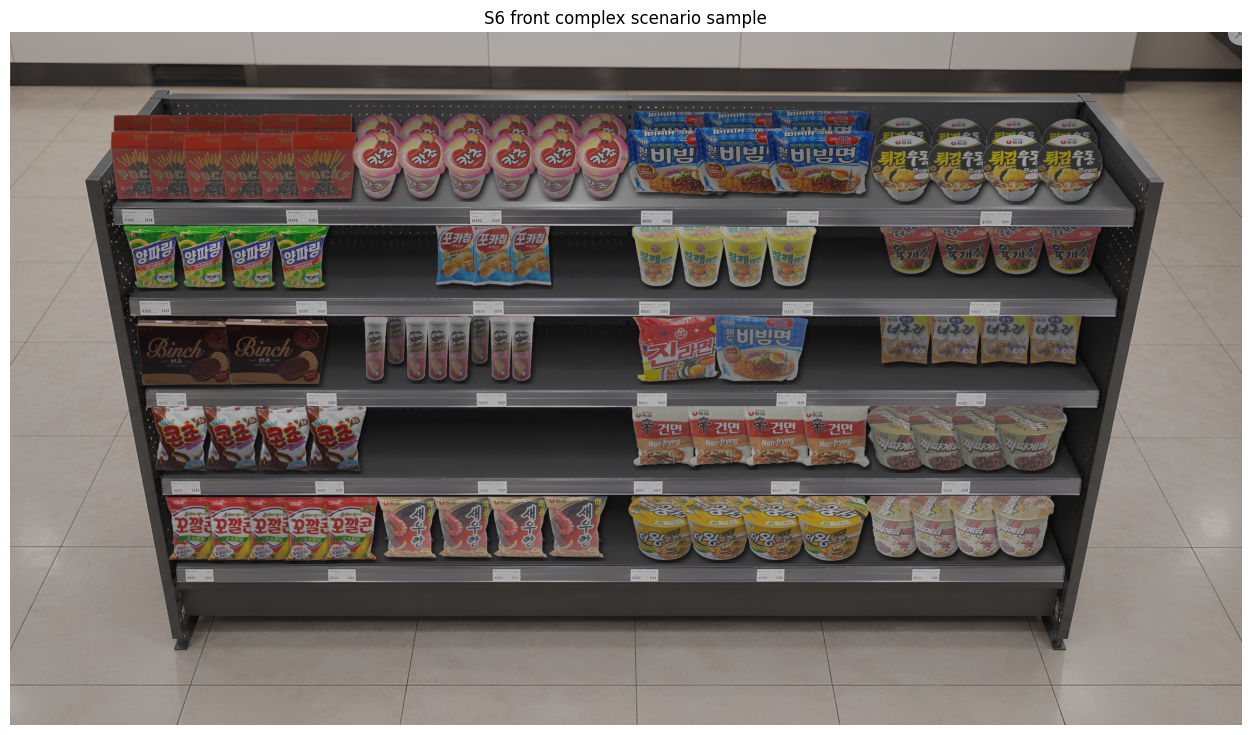

In [8]:
# ============================================================
# S6 정면 합성 + 이미지/라벨 저장
# 복합 상황 280장
# helper 함수 포함 통합 셀
# 전제: 위 셀에서 BASE_DIR, synth, labeler import 완료
# ============================================================

from tqdm.auto import tqdm
from PIL import Image, ImageEnhance
import time
import random
import numpy as np
import re

SCENARIO_CODE = 'S6'
SCENARIO_NAME = '복합 상황'

NUM_IMAGES = 200
BASE_SEED = 660660


# ------------------------------------------------------------
# 0. 이 셀 단독 실행용 helper
# ------------------------------------------------------------

def get_next_start_index(image_dir, scenario_code):
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3}})\.png$')
    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)
        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1


def sample_nonempty_subset(items, prob_range=(0.1, 0.4), keep_at_least_one_unselected=False):
    """
    개수를 직접 고정하지 않고, 매번 다른 확률로 subset을 랜덤 샘플링한다.
    """
    items = list(items)

    if len(items) == 0:
        return []

    p = random.uniform(*prob_range)
    selected = [x for x in items if random.random() < p]

    if not selected:
        selected = [random.choice(items)]

    if keep_at_least_one_unselected and len(items) > 1 and len(selected) == len(items):
        drop_one = random.choice(selected)
        selected = [x for x in selected if x != drop_one]

        if not selected:
            selected = [random.choice(items)]

    return selected


def apply_random_lighting(image):
    """
    S6 복합 상황 안에 조도 변화도 함께 적용한다.
    너무 어두우면 YOLO가 인식하기 어려우므로 최소 밝기는 제한한다.
    """
    lighting_mode = random.choice(["dark", "normal", "bright"])

    if lighting_mode == "dark":
        brightness_factor = random.uniform(0.68, 0.84)
        contrast_factor = random.uniform(0.90, 1.02)

    elif lighting_mode == "normal":
        brightness_factor = random.uniform(0.92, 1.06)
        contrast_factor = random.uniform(0.95, 1.05)

    else:
        brightness_factor = random.uniform(1.08, 1.22)
        contrast_factor = random.uniform(0.96, 1.08)

    image = ImageEnhance.Brightness(image).enhance(brightness_factor)
    image = ImageEnhance.Contrast(image).enhance(contrast_factor)

    lighting_info = {
        "lighting_mode": lighting_mode,
        "brightness_factor": round(brightness_factor, 4),
        "contrast_factor": round(contrast_factor, 4),
    }

    return image, lighting_info


def get_resized_width_for_slot(product_dir, slot):
    """
    해당 slot에 상품을 붙였을 때의 예상 가로 크기를 계산한다.
    S5 오진열 후보를 고를 때 기준 상품과 크기가 비슷한 상품만 선택하기 위함.
    """
    product_path = synth.get_png_by_slot_view(
        product_dir=product_dir,
        slot=slot,
        image_type="s",
    )

    if product_path is None:
        return None

    img = Image.open(product_path).convert("RGBA")
    w, h = img.size

    if h <= 0:
        return None

    dynamic_scale = synth.get_scale_by_slot(slot)
    slot_height = slot["y2"] - slot["y1"]

    target_h = int(slot_height * dynamic_scale)
    resize_ratio = target_h / h
    resized_w = int(w * resize_ratio)

    return resized_w


def choose_wrong_item_by_width(all_items, target, slot, width_tolerance=0.10):
    """
    기준 상품과 합성 후 예상 가로폭이 비슷한 상품 중에서 오진열 후보를 선택한다.
    원본 S5 로직 유지.
    """
    base_width = get_resized_width_for_slot(
        target["target_product_dir"],
        slot,
    )

    if base_width is None:
        return None

    candidates = []

    for item in all_items:
        if item["zone_id"] != target["zone_id"]:
            continue

        if item["product_dir"] == target["target_product_dir"]:
            continue

        wrong_width = get_resized_width_for_slot(
            item["product_dir"],
            slot,
        )

        if wrong_width is None:
            continue

        width_diff = abs(wrong_width - base_width) / base_width

        if width_diff <= width_tolerance:
            candidates.append(item)

    if not candidates:
        return None

    return random.choice(candidates)


def paste_single_wrong_product_at_index(
    result,
    base_product_dir,
    wrong_product_dir,
    slot,
    front_qty,
    misplaced_index,
):
    """
    S5/S6 오진열 전용:
    기준 상품 배열의 position_index를 그대로 사용해서
    해당 위치 1개만 wrong_product로 붙인다.
    """
    base_product_path = synth.get_png_by_slot_view(
        product_dir=base_product_dir,
        slot=slot,
        image_type="s",
    )

    wrong_product_path = synth.get_png_by_slot_view(
        product_dir=wrong_product_dir,
        slot=slot,
        image_type="s",
    )

    if base_product_path is None or wrong_product_path is None:
        return None

    base_product = Image.open(base_product_path).convert("RGBA")
    wrong_product = Image.open(wrong_product_path).convert("RGBA")

    anchor_x = slot["anchor_x"]
    anchor_y = slot["anchor_y"]

    dynamic_scale = synth.get_scale_by_slot(slot)
    slot_height = slot["y2"] - slot["y1"]

    base_product_h = int(slot_height * dynamic_scale)
    base_ratio = base_product_h / base_product.height
    base_product_w = int(base_product.width * base_ratio)

    slot_left = slot["x1"]
    slot_right = slot["x2"]

    min_center_x = slot_left + base_product_w / 2
    max_center_x = slot_right - base_product_w / 2

    if max_center_x < min_center_x:
        max_width = max(20, slot_right - slot_left)
        shrink_ratio = max_width / base_product_w * 0.95

        base_product_w = int(base_product_w * shrink_ratio)
        base_product_h = int(base_product_h * shrink_ratio)

        min_center_x = slot_left + base_product_w / 2
        max_center_x = slot_right - base_product_w / 2

    start_center_x = max(anchor_x, min_center_x)
    start_center_x = min(start_center_x, max_center_x)

    if front_qty <= 1:
        step_x = 0
    else:
        default_overlap_ratio = 0.15
        default_step_x = base_product_w * (1 - default_overlap_ratio)
        available_center_width = max_center_x - start_center_x

        step_x = min(default_step_x, available_center_width / (front_qty - 1))
        step_x = max(0, step_x)

    center_x_list = [
        start_center_x + i * step_x
        for i in range(front_qty)
    ]

    if misplaced_index >= len(center_x_list):
        return None

    size_jitter = random.uniform(0.98, 1.02)

    target_h = int(base_product_h * size_jitter)

    wrong_w, wrong_h = wrong_product.size
    resize_ratio = target_h / wrong_h

    target_w = int(wrong_w * resize_ratio)

    if front_qty <= 1 or len(center_x_list) <= 1:
        item_cell_w = slot_right - slot_left
    else:
        item_cell_w = abs(center_x_list[1] - center_x_list[0])

    max_w_by_base = int(base_product_w * 1.50)
    max_w_by_cell = int(item_cell_w * 1.50)
    max_w_by_slot = int((slot_right - slot_left) / max(front_qty, 1) * 1.70)

    max_allowed_w = max(
        20,
        min(max_w_by_base, max_w_by_cell, max_w_by_slot)
    )

    if target_w > max_allowed_w:
        shrink = max_allowed_w / target_w
        target_w = int(target_w * shrink)
        target_h = int(target_h * shrink)

    min_allowed_h = int(base_product_h * 0.90)

    if target_h < min_allowed_h:
        grow = min_allowed_h / target_h
        grown_w = int(target_w * grow)
        grown_h = int(target_h * grow)

        if grown_w <= max_allowed_w:
            target_w = grown_w
            target_h = grown_h

    target_w = max(1, int(target_w))
    target_h = max(1, int(target_h))

    wrong_product = wrong_product.resize(
        (target_w, target_h),
        resample=Image.LANCZOS
    )

    wrong_product = synth.adjust_product_color(wrong_product)

    angle = random.uniform(-0.2, 0.2)
    wrong_product = wrong_product.rotate(
        angle,
        expand=True,
        resample=Image.BICUBIC
    )

    rotated_w, rotated_h = wrong_product.size

    item_anchor_x = center_x_list[misplaced_index]
    item_anchor_y = anchor_y

    paste_x = int(item_anchor_x - rotated_w / 2)
    paste_y = int(item_anchor_y - rotated_h)

    if paste_x < slot["x1"]:
        paste_x = slot["x1"]

    if paste_x + rotated_w > slot["x2"]:
        paste_x = slot["x2"] - rotated_w

    paste_x += random.randint(-1, 1)
    paste_y += random.randint(-1, 1)

    synth.add_shadow(result, wrong_product, paste_x, paste_y)
    result.paste(wrong_product, (paste_x, paste_y), wrong_product)

    wrong_product_id, wrong_product_name = synth.get_product_info_from_dir(
        wrong_product_dir
    )

    return {
        "bbox": [paste_x, paste_y, paste_x + rotated_w, paste_y + rotated_h],
        "source_png": str(wrong_product_path),
        "angle_info": synth.parse_png_info(wrong_product_path),
        "depth_row": "front",
        "position_index": misplaced_index,
        "is_misplaced_item": True,
        "wrong_product_id": str(wrong_product_id),
        "wrong_product_name": wrong_product_name,
    }


def make_s6_slot_plan(ctx, seed):
    """
    S6 복합 상황 slot_plan 생성.
    한 이미지 안에 S1/S2/S3/S4/S5 상황을 섞는다.
    조도 변화 S7은 렌더링 후 apply_random_lighting()에서 적용한다.
    """
    random.seed(seed)
    np.random.seed(seed)

    slot_plan = synth.make_normal_slot_plan(ctx)
    all_slot_ids = list(slot_plan.keys())

    s6_logs = {
        "S1_partial_front_missing": [],
        "S2_empty_front": [],
        "S3_empty_column": [],
        "S4_sku_absent": [],
        "S5_misplaced": [],
    }

    used_slot_ids = set()

    # ------------------------------------------------------------
    # S1: 앞줄 일부 결손
    # ------------------------------------------------------------
    available = [sid for sid in all_slot_ids if sid not in used_slot_ids]
    s1_slot_ids = sample_nonempty_subset(
        available,
        prob_range=(0.05, 0.15),
        keep_at_least_one_unselected=True
    )

    for slot_id in s1_slot_ids:
        target = slot_plan[slot_id]

        normal_front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        normal_back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', normal_front_qty)))

        if normal_front_qty <= 1:
            continue

        max_missing_qty = max(1, normal_front_qty // 2)
        missing_qty = random.randint(1, max_missing_qty)
        front_missing_indices = sorted(random.sample(range(normal_front_qty), k=missing_qty))

        target.update({
            'scenario_code': 'S6',
            'sub_scenario_code': 'S1',
            'scenario_name': '복합 상황',
            'action': 'partial_front_missing',

            'list_up': False,
            'final_status': '정상',
            'status_code': 'NORMAL',
            'status_label': '정상',

            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            'required_front_qty': normal_front_qty,
            'required_back_qty': normal_back_qty,
            'front_display_qty': normal_front_qty - missing_qty,
            'back_display_qty': normal_back_qty,

            'front_missing_indices': front_missing_indices,
            'back_missing_indices': [],
            'back_visible_indices': front_missing_indices,

            'front_missing_qty': missing_qty,
            'back_missing_qty': 0,
            'missing_qty': missing_qty,
            'missing_ratio': round(missing_qty / max(1, normal_front_qty + normal_back_qty), 4),

            'reduced_front_qty': normal_front_qty - missing_qty,
            'target_column_index': None,
            'extra_misplaced_items': [],

            'is_misplaced': False,
            'is_front_depleted': False,
            'is_slot_empty': False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S1_partial_front_missing"].append({
            'slot_id': slot_id,
            'product_id': target.get('target_product_id'),
            'product_name': target.get('target_product_name'),
            'front_missing_indices': front_missing_indices,
            'missing_qty': missing_qty,
        })

    # ------------------------------------------------------------
    # S2: 앞줄 전체 공백
    # ------------------------------------------------------------
    available = [sid for sid in all_slot_ids if sid not in used_slot_ids]
    s2_slot_ids = sample_nonempty_subset(
        available,
        prob_range=(0.04, 0.12),
        keep_at_least_one_unselected=True
    )

    for slot_id in s2_slot_ids:
        target = slot_plan[slot_id]

        normal_front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        normal_back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', normal_front_qty)))

        front_missing_indices = list(range(normal_front_qty))

        target.update({
            'scenario_code': 'S6',
            'sub_scenario_code': 'S2',
            'scenario_name': '복합 상황',
            'action': 'empty_front',

            'list_up': True,
            'final_status': '보충 필요 / 발주 필요',
            'status_code': 'REPLENISH_REQUIRED',
            'status_label': '보충 필요',

            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            'required_front_qty': normal_front_qty,
            'required_back_qty': normal_back_qty,
            'front_display_qty': 0,
            'back_display_qty': normal_back_qty,

            'front_missing_indices': front_missing_indices,
            'back_missing_indices': [],
            'back_visible_indices': None,

            'front_missing_qty': normal_front_qty,
            'back_missing_qty': 0,
            'missing_qty': normal_front_qty,
            'missing_ratio': round(normal_front_qty / max(1, normal_front_qty + normal_back_qty), 4),

            'reduced_front_qty': 0,
            'target_column_index': None,
            'extra_misplaced_items': [],

            'is_misplaced': False,
            'is_front_depleted': True,
            'is_slot_empty': False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S2_empty_front"].append({
            'slot_id': slot_id,
            'product_id': target.get('target_product_id'),
            'product_name': target.get('target_product_name'),
            'front_missing_indices': front_missing_indices,
            'missing_qty': normal_front_qty,
        })

    # ------------------------------------------------------------
    # S3: 열 단위 공백
    # ------------------------------------------------------------
    available = [sid for sid in all_slot_ids if sid not in used_slot_ids]
    s3_slot_ids = sample_nonempty_subset(
        available,
        prob_range=(0.04, 0.12),
        keep_at_least_one_unselected=True
    )

    for slot_id in s3_slot_ids:
        target = slot_plan[slot_id]

        normal_front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        normal_back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', normal_front_qty)))

        if normal_front_qty <= 1:
            continue

        all_cols = list(range(normal_front_qty))
        target_cols = sample_nonempty_subset(
            all_cols,
            prob_range=(0.20, 0.65),
            keep_at_least_one_unselected=True
        )

        target_cols = sorted(set(target_cols))

        front_missing_indices = target_cols
        back_missing_indices = [
            c for c in target_cols
            if c < normal_back_qty
        ]

        missing_qty = len(front_missing_indices) + len(back_missing_indices)

        target.update({
            'scenario_code': 'S6',
            'sub_scenario_code': 'S3',
            'scenario_name': '복합 상황',
            'action': 'empty_column',

            'list_up': True,
            'final_status': '보충 필요 / 발주 필요',
            'status_code': 'REPLENISH_REQUIRED',
            'status_label': '보충 필요',

            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            'required_front_qty': normal_front_qty,
            'required_back_qty': normal_back_qty,
            'front_display_qty': normal_front_qty - len(front_missing_indices),
            'back_display_qty': normal_back_qty - len(back_missing_indices),

            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'back_visible_indices': None,

            'front_missing_qty': len(front_missing_indices),
            'back_missing_qty': len(back_missing_indices),
            'missing_qty': missing_qty,
            'missing_ratio': round(missing_qty / max(1, normal_front_qty + normal_back_qty), 4),

            'reduced_front_qty': normal_front_qty - len(front_missing_indices),
            'target_column_index': target_cols,
            'extra_misplaced_items': [],

            'is_misplaced': False,
            'is_front_depleted': False,
            'is_slot_empty': False,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S3_empty_column"].append({
            'slot_id': slot_id,
            'product_id': target.get('target_product_id'),
            'product_name': target.get('target_product_name'),
            'target_column_index': target_cols,
            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'missing_qty': missing_qty,
        })

    # ------------------------------------------------------------
    # S4: SKU 완전 부재
    # ------------------------------------------------------------
    available = [sid for sid in all_slot_ids if sid not in used_slot_ids]
    s4_slot_ids = sample_nonempty_subset(
        available,
        prob_range=(0.03, 0.10),
        keep_at_least_one_unselected=True
    )

    for slot_id in s4_slot_ids:
        target = slot_plan[slot_id]

        normal_front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        normal_back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', normal_front_qty)))

        front_missing_indices = list(range(normal_front_qty))
        back_missing_indices = list(range(normal_back_qty))
        missing_qty = normal_front_qty + normal_back_qty

        target.update({
            'scenario_code': 'S6',
            'sub_scenario_code': 'S4',
            'scenario_name': '복합 상황',
            'action': 'sku_absent',

            'list_up': True,
            'final_status': '보충 필요 / 발주 필요',
            'status_code': 'ORDER_REQUIRED',
            'status_label': '발주 필요',

            'actual_product_id': None,
            'actual_product_name': None,
            'actual_product_dir': None,

            'display_qty': normal_front_qty,
            'back_display_qty': normal_back_qty,

            'required_front_qty': normal_front_qty,
            'required_back_qty': normal_back_qty,
            'front_display_qty': 0,
            'back_display_qty': 0,

            'front_missing_indices': front_missing_indices,
            'back_missing_indices': back_missing_indices,
            'back_visible_indices': [],

            'front_missing_qty': normal_front_qty,
            'back_missing_qty': normal_back_qty,
            'missing_qty': missing_qty,
            'missing_ratio': 1.0,

            'reduced_front_qty': 0,
            'target_column_index': None,
            'extra_misplaced_items': [],

            'is_misplaced': False,
            'is_front_depleted': True,
            'is_slot_empty': True,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S4_sku_absent"].append({
            'slot_id': slot_id,
            'product_id': target.get('target_product_id'),
            'product_name': target.get('target_product_name'),
            'missing_qty': missing_qty,
        })

    # ------------------------------------------------------------
    # S5: 오진열
    # ------------------------------------------------------------
    all_items = synth.collect_slot_items(ctx)

    available = [sid for sid in all_slot_ids if sid not in used_slot_ids]
    s5_slot_ids = sample_nonempty_subset(
        available,
        prob_range=(0.03, 0.10),
        keep_at_least_one_unselected=True
    )

    for slot_id in s5_slot_ids:
        target = slot_plan[slot_id]

        front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', front_qty)))

        if front_qty <= 0:
            continue

        misplaced_index = random.randrange(front_qty)

        wrong_item = choose_wrong_item_by_width(
            all_items=all_items,
            target=target,
            slot=target["slot"],
            width_tolerance=0.10,
        )

        if wrong_item is None:
            continue

        wrong_product_id = wrong_item["product_id"]
        wrong_product_name = wrong_item["product_name"]

        target.update({
            'scenario_code': 'S6',
            'sub_scenario_code': 'S5',
            'scenario_name': '복합 상황',
            'action': 'misplaced_one_item',

            'list_up': True,
            'final_status': '확인 필요',
            'status_code': 'CHECK_REQUIRED',
            'status_label': '확인 필요',

            'actual_product_dir': target['target_product_dir'],
            'actual_product_id': target['target_product_id'],
            'actual_product_name': target['target_product_name'],

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            'required_front_qty': front_qty,
            'required_back_qty': back_qty,
            'front_display_qty': front_qty,
            'back_display_qty': back_qty,

            'front_missing_indices': [misplaced_index],
            'back_missing_indices': [misplaced_index],
            'back_visible_indices': None,

            'front_missing_qty': 0,
            'back_missing_qty': 0,
            'missing_qty': 0,
            'missing_ratio': 0.0,

            'reduced_front_qty': front_qty,
            'target_column_index': None,

            'extra_misplaced_items': [],
            'manual_misplaced_items': [{
                "position_index": misplaced_index,
                "product_dir": wrong_item["product_dir"],
                "product_id": str(wrong_product_id),
                "product_name": wrong_product_name,
            }],

            'is_misplaced': True,
            'is_front_depleted': False,
            'is_slot_empty': False,

            'misplaced_index': misplaced_index,
            'misplaced_product_id': str(wrong_product_id),
            'misplaced_product_name': wrong_product_name,
        })

        used_slot_ids.add(slot_id)

        s6_logs["S5_misplaced"].append({
            'slot_id': slot_id,
            'base_product_id': target.get('target_product_id'),
            'base_product_name': target.get('target_product_name'),
            'misplaced_index': misplaced_index,
            'wrong_product_id': str(wrong_product_id),
            'wrong_product_name': wrong_product_name,
        })

    # ------------------------------------------------------------
    # 나머지는 정상
    # ------------------------------------------------------------
    for slot_id, target in slot_plan.items():
        if slot_id in used_slot_ids:
            continue

        front_qty = int(target.get('normal_front_qty', target.get('display_qty', 0)))
        back_qty = int(target.get('normal_back_qty', target.get('back_display_qty', front_qty)))

        target.update({
            'scenario_code': 'S6',
            'sub_scenario_code': 'S0',
            'scenario_name': '복합 상황',
            'action': 'normal',

            'list_up': False,
            'final_status': '정상',
            'status_code': 'NORMAL',
            'status_label': '정상',

            'display_qty': front_qty,
            'back_display_qty': back_qty,

            'required_front_qty': front_qty,
            'required_back_qty': back_qty,
            'front_display_qty': front_qty,
            'back_display_qty': back_qty,

            'front_missing_indices': [],
            'back_missing_indices': [],
            'back_visible_indices': None,
            'extra_misplaced_items': [],
            'manual_misplaced_items': [],

            'front_missing_qty': 0,
            'back_missing_qty': 0,
            'missing_qty': 0,
            'missing_ratio': 0.0,

            'reduced_front_qty': front_qty,
            'target_column_index': None,

            'is_misplaced': False,
            'is_front_depleted': False,
            'is_slot_empty': False,
        })

    return slot_plan, s6_logs


# ------------------------------------------------------------
# 1. SAHI 기준 최종 라벨 저장 경로
# ------------------------------------------------------------

IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'front' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'front' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'front' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'front' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None
last_label_result = None

start_time = time.time()

pbar = tqdm(range(NUM_IMAGES), desc=f'{SCENARIO_CODE} 정면 생성 중', unit='img')

for image_idx in pbar:
    seed = BASE_SEED + image_idx

    random.seed(seed)
    np.random.seed(seed)

    if hasattr(synth, 'reset_random_seed'):
        synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 2. 이미지마다 context 새로 생성
    # ------------------------------------------------------------
    t_ctx0 = time.time()

    ctx_i = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_정면.png',
        seed=seed,
    )

    t_ctx1 = time.time()

    # ------------------------------------------------------------
    # 3. S6 복합 상황 slot_plan 생성
    # ------------------------------------------------------------
    slot_plan, s6_logs = make_s6_slot_plan(
        ctx=ctx_i,
        seed=seed
    )

    # ------------------------------------------------------------
    # 4. 렌더링
    # ------------------------------------------------------------
    t_render0 = time.time()

    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx_i,
        slot_plan=slot_plan,
        seed=seed
    )

    # ------------------------------------------------------------
    # 5. S5 오진열 수동 합성
    # ------------------------------------------------------------
    manual_misplaced_count = 0

    for slot_id, target in slot_plan.items():
        manual_items = target.get("manual_misplaced_items", [])

        for manual in manual_items:
            wrong_obj = paste_single_wrong_product_at_index(
                result=result,
                base_product_dir=target["target_product_dir"],
                wrong_product_dir=manual["product_dir"],
                slot=target["slot"],
                front_qty=int(target["normal_front_qty"]),
                misplaced_index=int(manual["position_index"]),
            )

            if wrong_obj is not None:
                manual_misplaced_count += 1

                objects.append({
                    "object_id": len(objects) + 1,
                    "slot_id": slot_id,
                    "zone_id": target.get("zone_id"),
                    "category": target.get("category"),
                    "row_no": target["slot"]["row_no"],
                    "col_no": target["slot"]["col_no"],
                    "product_no": target.get("product_no"),

                    "product_id": str(manual["product_id"]),
                    "product_name": manual["product_name"],

                    "actual_product_id": str(manual["product_id"]),
                    "actual_product_name": manual["product_name"],

                    "target_product_id": target.get("target_product_id"),
                    "target_product_name": target.get("target_product_name"),

                    "expected_product_id": target.get("target_product_id"),
                    "expected_product_name": target.get("target_product_name"),

                    "scenario_code": SCENARIO_CODE,
                    "sub_scenario_code": "S5",
                    "scenario_name": SCENARIO_NAME,
                    "action": "misplaced_one_item",
                    "is_misplaced": True,

                    "bbox": wrong_obj["bbox"],
                    "source_png": wrong_obj["source_png"],
                    "angle_info": wrong_obj["angle_info"],
                    "depth_row": "front",
                    "depth_gt": "front",
                    "position_index": int(manual["position_index"]),
                    "is_misplaced_item": True,
                })

    # wrong 상품을 붙인 뒤 선반 앞턱을 다시 덮어 자연스럽게 보이게 함
    if 'combined_occluder' in ctx_i and ctx_i['combined_occluder'] is not None:
        result.alpha_composite(ctx_i['combined_occluder'])

    # ------------------------------------------------------------
    # 6. S6에는 조도 변화도 함께 적용
    # ------------------------------------------------------------
    result, lighting_info = apply_random_lighting(result)

    for slot_label in slot_labels:
        if isinstance(slot_label, dict):
            slot_label['lighting_info'] = lighting_info

    t_render1 = time.time()

    # ------------------------------------------------------------
    # 7. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png'
    yolo_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt'
    json_name = f'synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json'

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 8. 이미지 + SAHI 기준 라벨 3종 저장
    # ------------------------------------------------------------
    t_label0 = time.time()

    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx_i,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view='front',
        settings_extra={
            'source_notebook': 'S6_정면시나리오_합성.ipynb',
            'label_structure': 'sahi_full_image',
            'scenario_rule': 'complex scenario',
            'ctx_reuse': False,
            'random_product_layout': True,
            'included_sub_scenarios': ['S1', 'S2', 'S3', 'S4', 'S5', 'S7'],
            'lighting_info': lighting_info,
        }
    )

    t_label1 = time.time()

    saved_paths.append(save_path)
    last_result = result
    last_label_result = label_result

    ctx_sec = round(t_ctx1 - t_ctx0, 2)
    render_sec = round(t_render1 - t_render0, 2)
    label_save_sec = round(t_label1 - t_label0, 2)
    total_sec = round(t_label1 - t_ctx0, 2)

    n_s1 = len(s6_logs.get("S1_partial_front_missing", []))
    n_s2 = len(s6_logs.get("S2_empty_front", []))
    n_s3 = len(s6_logs.get("S3_empty_column", []))
    n_s4 = len(s6_logs.get("S4_sku_absent", []))
    n_s5 = len(s6_logs.get("S5_misplaced", []))

    generation_logs.append({
        'file_name': save_name,
        'seed': seed,
        'scenario_code': SCENARIO_CODE,
        'scenario_name': SCENARIO_NAME,

        'lighting_info': lighting_info,

        'n_s1_partial_front_missing': n_s1,
        'n_s2_empty_front': n_s2,
        'n_s3_empty_column': n_s3,
        'n_s4_sku_absent': n_s4,
        'n_s5_misplaced': n_s5,
        'n_manual_misplaced_objects': manual_misplaced_count,

        'details': s6_logs,

        'n_objects': len(objects),
        'n_slots': len(slot_labels),

        'ctx_sec': ctx_sec,
        'render_sec': render_sec,
        'label_save_sec': label_save_sec,
        'total_sec': total_sec,

        'image_path': str(save_path),
        'product_yolo_path': str(product_yolo_path),
        'shelf_lip_yolo_path': str(shelf_lip_yolo_path),
        'json_path': str(json_path),
        'label_result': label_result,
    })

    if (image_idx + 1) % 20 == 0 or (image_idx + 1) == NUM_IMAGES:
        elapsed = time.time() - start_time
        avg_sec = elapsed / (image_idx + 1)
        remain_sec = avg_sec * (NUM_IMAGES - (image_idx + 1))

        print(
            f'[{image_idx + 1}/{NUM_IMAGES}] 완료 | '
            f'최근 파일: {save_name} | '
            f'S1:{n_s1}, S2:{n_s2}, S3:{n_s3}, S4:{n_s4}, S5:{n_s5} | '
            f'조도:{lighting_info["lighting_mode"]} | '
            f'ctx: {ctx_sec}초 | '
            f'render: {render_sec}초 | '
            f'label: {label_save_sec}초 | '
            f'평균: {avg_sec:.2f}초/장 | '
            f'예상 남은 시간: {remain_sec/60:.1f}분'
        )

total_time = time.time() - start_time

print('\nS6 정면 생성 완료')
print(f'총 생성 수: {len(saved_paths)}장')
print(f'총 소요 시간: {total_time/60:.2f}분')
print(f'평균 시간: {total_time / len(saved_paths):.2f}초/장')

print('이미지 저장 폴더:', IMAGE_DIR)
print('상품 YOLO 저장 폴더:', PRODUCT_YOLO_DIR)
print('선반 앞턱 YOLO-seg 저장 폴더:', SHELF_LIP_YOLO_DIR)
print('slot_state JSON 저장 폴더:', JSON_DIR)

print('\n처음 5개 파일:')
for p in saved_paths[:5]:
    print('-', p.name)

print('\n마지막 이미지:', saved_paths[-1])
synth.show_image(last_result, title=f'{SCENARIO_CODE} front complex scenario sample')

In [3]:
# from PIL import ImageEnhance

# def apply_random_lighting(image):
#     """
#     S6 복합 상황 안에 조도 변화도 함께 적용한다.
#     너무 어두우면 YOLO가 인식하기 어려우므로 최소 밝기는 제한한다.
#     """

#     lighting_mode = random.choice(["dark", "normal", "bright"])

#     if lighting_mode == "dark":
#         brightness_factor = random.uniform(0.68, 0.84)
#         contrast_factor = random.uniform(0.90, 1.02)

#     elif lighting_mode == "normal":
#         brightness_factor = random.uniform(0.92, 1.06)
#         contrast_factor = random.uniform(0.95, 1.05)

#     else:
#         brightness_factor = random.uniform(1.08, 1.22)
#         contrast_factor = random.uniform(0.96, 1.08)

#     image = ImageEnhance.Brightness(image).enhance(brightness_factor)
#     image = ImageEnhance.Contrast(image).enhance(contrast_factor)

#     lighting_info = {
#         "lighting_mode": lighting_mode,
#         "brightness_factor": round(brightness_factor, 4),
#         "contrast_factor": round(contrast_factor, 4),
#     }

#     return image, lighting_info

In [4]:
# def sample_available_slot_ids(slot_ids, used_slot_ids, k):
#     available = [
#         slot_id for slot_id in slot_ids
#         if slot_id not in used_slot_ids
#     ]

#     if len(available) == 0:
#         return []

#     k = min(k, len(available))
#     return random.sample(available, k=k)


# def make_s6_slot_plan(ctx, seed=None):
#     """
#     S6 복합 상황:
#     - S1 앞줄 일부 결손
#     - S2 앞줄 전체 공백
#     - S3 열 단위 공백
#     - S4 SKU 완전 부재
#     - S5 오진열

#     주의:
#     - S5 오진열은 줄 전체가 아니라 상품 1개만 잘못 들어간 상황이다.
#     - 현재 py 파일 구조에서는 extra_misplaced_items로 wrong 상품을 추가 합성한다.
#     """

#     if seed is not None:
#         random.seed(seed)

#     slot_plan = synth.make_normal_slot_plan(ctx)

#     # S5 오진열 후보를 고를 때 상품 비율 비교용
#     all_items = synth.collect_slot_items(ctx)

#     slot_ids = list(slot_plan.keys())
#     used_slot_ids = set()

#     s6_logs = {
#         "S1_partial_front_missing": [],
#         "S2_empty_front": [],
#         "S3_empty_column": [],
#         "S4_sku_absent": [],
#         "S5_misplaced": [],
#     }

#     # -------------------------------------------------
#     # S1. 앞줄 일부 결손
#     # -------------------------------------------------
#     s1_target_ids = sample_available_slot_ids(
#         slot_ids=slot_ids,
#         used_slot_ids=used_slot_ids,
#         k=random.randint(3, 5)
#     )

#     for slot_id in s1_target_ids:
#         target = slot_plan[slot_id]
#         normal_qty = int(target["normal_front_qty"])

#         if normal_qty <= 1:
#             continue

#         missing_qty = random.randint(1, max(1, normal_qty // 2))

#         missing_indices = sorted(
#             random.sample(range(normal_qty), k=missing_qty)
#         )

#         # 맨 위층은 앞줄 일부 결손이어도 뒷줄 전체가 보여야 함
#         if target["slot"]["row_no"] == 1:
#             back_visible_indices = None
#         else:
#             back_visible_indices = missing_indices

#         target.update({
#             "scenario_code": "S6",
#             "action": "partial_front_missing",
#             "list_up": False,
#             "final_status": "정상 또는 모니터링",

#             "display_qty": normal_qty,
#             "back_display_qty": normal_qty,

#             "front_missing_indices": missing_indices,
#             "back_missing_indices": [],
#             "back_visible_indices": back_visible_indices,

#             "missing_qty": missing_qty,
#             "reduced_front_qty": normal_qty - missing_qty,
#         })

#         used_slot_ids.add(slot_id)

#         s6_logs["S1_partial_front_missing"].append({
#             "slot_id": slot_id,
#             "product_id": target["target_product_id"],
#             "product_name": target["target_product_name"],
#             "normal_qty": normal_qty,
#             "current_front_qty": normal_qty - missing_qty,
#             "missing_qty": missing_qty,
#             "missing_indices": missing_indices,
#         })

#     # -------------------------------------------------
#     # S2. 앞줄 전체 공백
#     # -------------------------------------------------
#     s2_target_ids = sample_available_slot_ids(
#         slot_ids=slot_ids,
#         used_slot_ids=used_slot_ids,
#         k=random.randint(1, 2)
#     )

#     for slot_id in s2_target_ids:
#         target = slot_plan[slot_id]
#         normal_qty = int(target["normal_front_qty"])

#         target.update({
#             "scenario_code": "S6",
#             "action": "empty_front",
#             "list_up": True,
#             "final_status": "보충 필요 / 발주 필요",

#             "display_qty": normal_qty,
#             "back_display_qty": normal_qty,

#             "front_missing_indices": list(range(normal_qty)),
#             "back_missing_indices": [],

#             # 앞줄 전체 공백이므로 뒷줄은 보이게 함
#             "back_visible_indices": list(range(normal_qty)),

#             "missing_qty": normal_qty,
#             "reduced_front_qty": 0,
#         })

#         used_slot_ids.add(slot_id)

#         s6_logs["S2_empty_front"].append({
#             "slot_id": slot_id,
#             "product_id": target["target_product_id"],
#             "product_name": target["target_product_name"],
#             "normal_qty": normal_qty,
#             "current_front_qty": 0,
#             "missing_qty": normal_qty,
#             "missing_indices": list(range(normal_qty)),
#         })

#     # -------------------------------------------------
#     # S3. 열 단위 공백
#     # 같은 slot 안에서 특정 index를 앞줄/뒷줄 모두 비움
#     # -------------------------------------------------
#     col_list = sorted(set(
#         target["slot"]["col_no"]
#         for target in slot_plan.values()
#     ))

#     target_col = random.choice(col_list)

#     same_col_slot_ids = [
#         slot_id
#         for slot_id, target in slot_plan.items()
#         if target["slot"]["col_no"] == target_col
#         and slot_id not in used_slot_ids
#     ]

#     if len(same_col_slot_ids) > 0:
#         s3_target_count = random.randint(1, min(2, len(same_col_slot_ids)))

#         s3_target_ids = random.sample(
#             same_col_slot_ids,
#             k=s3_target_count
#         )
#     else:
#         s3_target_ids = []

#     for slot_id in s3_target_ids:
#         target = slot_plan[slot_id]
#         normal_qty = int(target["normal_front_qty"])

#         if normal_qty <= 1:
#             continue

#         empty_col_count = random.randint(1, min(2, normal_qty))

#         empty_indices = sorted(
#             random.sample(range(normal_qty), k=empty_col_count)
#         )

#         target.update({
#             "scenario_code": "S6",
#             "action": "empty_column",
#             "list_up": True,
#             "final_status": "보충 필요 / 발주 필요",

#             "actual_product_dir": target["target_product_dir"],
#             "actual_product_id": target["target_product_id"],
#             "actual_product_name": target["target_product_name"],

#             "display_qty": normal_qty,
#             "back_display_qty": normal_qty,

#             "front_missing_indices": empty_indices,
#             "back_missing_indices": empty_indices,
#             "back_visible_indices": None,

#             "missing_qty": empty_col_count * 2,
#             "reduced_front_qty": normal_qty - empty_col_count,
#             "target_column_index": target_col,
#         })

#         used_slot_ids.add(slot_id)

#         s6_logs["S3_empty_column"].append({
#             "slot_id": slot_id,
#             "product_id": target["target_product_id"],
#             "product_name": target["target_product_name"],
#             "col_no": target_col,
#             "normal_qty": normal_qty,
#             "current_front_qty": normal_qty - empty_col_count,
#             "missing_qty": empty_col_count * 2,
#             "empty_indices": empty_indices,
#         })

#     # -------------------------------------------------
#     # S4. SKU 완전 부재
#     # -------------------------------------------------
#     s4_target_ids = sample_available_slot_ids(
#         slot_ids=slot_ids,
#         used_slot_ids=used_slot_ids,
#         k=random.randint(1, 2)
#     )

#     for slot_id in s4_target_ids:
#         target = slot_plan[slot_id]
#         normal_qty = int(target["normal_front_qty"])

#         target.update({
#             "scenario_code": "S6",
#             "action": "sku_absent",
#             "list_up": True,
#             "final_status": "보충 필요 / 발주 필요",

#             "actual_product_dir": None,
#             "actual_product_id": None,
#             "actual_product_name": None,

#             "display_qty": 0,
#             "back_display_qty": 0,

#             "front_missing_indices": list(range(normal_qty)),
#             "back_missing_indices": list(range(normal_qty)),
#             "back_visible_indices": [],

#             "missing_qty": normal_qty * 2,
#             "reduced_front_qty": 0,
#         })

#         used_slot_ids.add(slot_id)

#         s6_logs["S4_sku_absent"].append({
#             "slot_id": slot_id,
#             "product_id": target["target_product_id"],
#             "product_name": target["target_product_name"],
#             "missing_qty": normal_qty * 2,
#         })

#         # -------------------------------------------------
#     # S5. 오진열
#     # slot 전체가 아니라, 앞줄 상품 1개만 wrong SKU로 교체
#     # py의 extra_misplaced_items를 쓰지 않고,
#     # render 이후 수동으로 wrong 상품 1개를 붙인다.
#     # -------------------------------------------------
#     s5_target_ids = sample_available_slot_ids(
#         slot_ids=slot_ids,
#         used_slot_ids=used_slot_ids,
#         k=random.randint(1, 2)
#     )

#     for slot_id in s5_target_ids:
#         target = slot_plan[slot_id]

#         target_category = target["category"]
#         target_product_id = target["target_product_id"]
#         normal_qty = int(target["normal_front_qty"])

#         if normal_qty <= 0:
#             continue

#         # # 같은 카테고리 안에서 원래 상품이 아닌 상품 중 선택
#         # same_category_candidates = [
#         #     other
#         #     for other in slot_plan.values()
#         #     if other["category"] == target_category
#         #     and other["target_product_id"] != target_product_id
#         # ]

#         # if len(same_category_candidates) == 0:
#         #     continue

#         # wrong = random.choice(same_category_candidates)

#         # wrong_product_dir = wrong["target_product_dir"]
#         # wrong_product_id = wrong["target_product_id"]
#         # wrong_product_name = wrong["target_product_name"]

#         # 가로 길이가 비슷한 상품 중에서 wrong 상품 선택
#         wrong_item = choose_wrong_item_by_width(
#             all_items=all_items,
#             target=target,
#             slot=target["slot"],
#             width_tolerance=0.1,
#         )

#         if wrong_item is None:
#             continue

#         wrong_product_dir = wrong_item["product_dir"]
#         wrong_product_id = wrong_item["product_id"]
#         wrong_product_name = wrong_item["product_name"]

#         # 오진열은 상품 1개만
#         misplaced_index = random.randrange(normal_qty)

#         # 기존 결손 index가 있다면 유지하면서 오진열 위치도 비움
#         existing_front_missing = set(target.get("front_missing_indices", []))
#         existing_back_missing = set(target.get("back_missing_indices", []))

#         existing_front_missing.add(misplaced_index)

#         # 중요:
#         # 오진열 위치의 뒷줄도 비워야 뒤 상품이 비쳐 보이지 않음
#         existing_back_missing.add(misplaced_index)

#         target.update({
#             "scenario_code": "S6",
#             "action": "misplaced_one_item",
#             "list_up": True,
#             "final_status": "확인 필요",
#             "is_misplaced": True,

#             # 기준 상품은 유지
#             "actual_product_dir": target["target_product_dir"],
#             "actual_product_id": target["target_product_id"],
#             "actual_product_name": target["target_product_name"],

#             "display_qty": normal_qty,
#             "back_display_qty": int(target["normal_back_qty"]),

#             # 기준 상품의 앞줄/뒷줄에서 해당 위치 제거
#             "front_missing_indices": sorted(existing_front_missing),
#             "back_missing_indices": sorted(existing_back_missing),

#             # extra 방식 금지
#             "extra_misplaced_items": [],

#             # 수동으로 붙일 정보 저장
#             "manual_misplaced_items": [
#                 {
#                     "product_dir": wrong_product_dir,
#                     "product_id": wrong_product_id,
#                     "product_name": wrong_product_name,
#                     "position_index": misplaced_index,
#                 }
#             ],

#             "missing_qty": 0,
#             "reduced_front_qty": normal_qty,
#         })

#         used_slot_ids.add(slot_id)

#         s6_logs["S5_misplaced"].append({
#             "slot_id": slot_id,
#             "expected_product_id": target_product_id,
#             "expected_product_name": target["target_product_name"],
#             "actual_product_id": wrong_product_id,
#             "actual_product_name": wrong_product_name,
#             "misplaced_index": misplaced_index,
#             "misplaced_count": 1,
#             "note": "기준 상품 1개를 비우고 render 후 wrong 상품 1개를 직접 붙임"
#         })

#     # -------------------------------------------------
#     # 나머지 정상 slot도 S6 메타정보 부여
#     # -------------------------------------------------
#     for slot_id, target in slot_plan.items():
#         if target.get("scenario_code") != "S6":
#             target.update({
#                 "scenario_code": "S6",
#                 "action": "normal",
#                 "list_up": False,
#                 "final_status": "정상",
#                 "missing_qty": 0,
#                 "reduced_front_qty": int(target["normal_front_qty"]),
#             })

#     return slot_plan, s6_logs

In [5]:
# from PIL import Image
# import random

# def get_resized_width_for_slot(product_dir, slot):
#     """
#     해당 slot에 상품을 붙였을 때의 예상 가로 크기를 계산한다.
#     실제 합성 함수와 비슷하게 slot 높이를 기준으로 resize한 뒤 width를 계산한다.
#     """
#     product_path = synth.get_png_by_slot_view(
#         product_dir=product_dir,
#         slot=slot,
#         image_type="s",
#     )

#     if product_path is None:
#         return None

#     img = Image.open(product_path).convert("RGBA")
#     w, h = img.size

#     if h <= 0:
#         return None

#     dynamic_scale = synth.get_scale_by_slot(slot)
#     slot_height = slot["y2"] - slot["y1"]

#     target_h = int(slot_height * dynamic_scale)
#     resize_ratio = target_h / h
#     resized_w = int(w * resize_ratio)

#     return resized_w


# def choose_wrong_item_by_width(all_items, target, slot, width_tolerance=0.25):
#     """
#     기준 상품과 '합성 후 예상 가로폭'이 비슷한 상품 중에서 오진열 후보를 선택한다.

#     width_tolerance=0.25:
#     기준 상품 width 대비 ±25% 범위 안에 드는 상품만 후보로 사용.
#     """
#     base_width = get_resized_width_for_slot(
#         target["target_product_dir"],
#         slot,
#     )

#     if base_width is None:
#         return None

#     candidates = []

#     for item in all_items:
#         if item["zone_id"] != target["zone_id"]:
#             continue

#         if item["product_dir"] == target["target_product_dir"]:
#             continue

#         wrong_width = get_resized_width_for_slot(
#             item["product_dir"],
#             slot,
#         )

#         if wrong_width is None:
#             continue

#         width_diff = abs(wrong_width - base_width) / base_width

#         if width_diff <= width_tolerance:
#             candidates.append(item)

#     # 후보가 없으면 억지로 이상한 상품 넣지 않음
#     if not candidates:
#         return None

#     return random.choice(candidates)


# def paste_single_wrong_product_at_index(
#     result,
#     base_product_dir,
#     wrong_product_dir,
#     slot,
#     front_qty,
#     misplaced_index,
# ):
#     """
#     S5/S6 오진열 전용:
#     - 기준 상품 배열의 position_index를 그대로 사용
#     - 해당 위치 1개만 wrong_product로 붙임
#     - wrong_product는 원본 비율 유지
#     """
#     base_product_path = synth.get_png_by_slot_view(
#         product_dir=base_product_dir,
#         slot=slot,
#         image_type="s",
#     )
#     wrong_product_path = synth.get_png_by_slot_view(
#         product_dir=wrong_product_dir,
#         slot=slot,
#         image_type="s",
#     )

#     if base_product_path is None or wrong_product_path is None:
#         return None

#     base_product = Image.open(base_product_path).convert("RGBA")
#     wrong_product = Image.open(wrong_product_path).convert("RGBA")

#     anchor_x = slot["anchor_x"]
#     anchor_y = slot["anchor_y"]

#     dynamic_scale = synth.get_scale_by_slot(slot)
#     slot_height = slot["y2"] - slot["y1"]

#     base_product_h = int(slot_height * dynamic_scale)
#     base_ratio = base_product_h / base_product.height
#     base_product_w = int(base_product.width * base_ratio)

#     slot_left = slot["x1"]
#     slot_right = slot["x2"]

#     min_center_x = slot_left + base_product_w / 2
#     max_center_x = slot_right - base_product_w / 2

#     if max_center_x < min_center_x:
#         max_width = max(20, slot_right - slot_left)
#         shrink_ratio = max_width / base_product_w * 0.95
#         base_product_w = int(base_product_w * shrink_ratio)
#         base_product_h = int(base_product_h * shrink_ratio)
#         min_center_x = slot_left + base_product_w / 2
#         max_center_x = slot_right - base_product_w / 2

#     start_center_x = max(anchor_x, min_center_x)
#     start_center_x = min(start_center_x, max_center_x)

#     if front_qty <= 1:
#         step_x = 0
#     else:
#         default_overlap_ratio = 0.15
#         default_step_x = base_product_w * (1 - default_overlap_ratio)
#         available_center_width = max_center_x - start_center_x
#         step_x = min(default_step_x, available_center_width / (front_qty - 1))
#         step_x = max(0, step_x)

#     center_x_list = [start_center_x + i * step_x for i in range(front_qty)]

#     if misplaced_index >= len(center_x_list):
#         return None

#     size_jitter = random.uniform(0.98, 1.02)

#     target_h = int(base_product_h * size_jitter)

#     wrong_w, wrong_h = wrong_product.size
#     resize_ratio = target_h / wrong_h
#     target_w = int(wrong_w * resize_ratio)

#     if front_qty <= 1 or len(center_x_list) <= 1:
#         item_cell_w = slot_right - slot_left
#     else:
#         item_cell_w = abs(center_x_list[1] - center_x_list[0])

#     max_w_by_base = int(base_product_w * 1.35)
#     max_w_by_cell = int(item_cell_w * 1.25)
#     max_w_by_slot = int((slot_right - slot_left) / max(front_qty, 1) * 1.50)

#     max_allowed_w = max(20, min(max_w_by_base, max_w_by_cell, max_w_by_slot))

#     if target_w > max_allowed_w:
#         shrink = max_allowed_w / target_w
#         target_w = int(target_w * shrink)
#         target_h = int(target_h * shrink)

#     min_allowed_h = int(base_product_h * 0.78)

#     if target_h < min_allowed_h:
#         grow = min_allowed_h / target_h
#         grown_w = int(target_w * grow)
#         grown_h = int(target_h * grow)

#         if grown_w <= max_allowed_w:
#             target_w = grown_w
#             target_h = grown_h

#     wrong_product = wrong_product.resize((target_w, target_h), resample=Image.LANCZOS)
#     wrong_product = synth.adjust_product_color(wrong_product)

#     angle = random.uniform(-0.2, 0.2)
#     wrong_product = wrong_product.rotate(angle, expand=True, resample=Image.BICUBIC)

#     rotated_w, rotated_h = wrong_product.size

#     item_anchor_x = center_x_list[misplaced_index]
#     item_anchor_y = anchor_y

#     paste_x = int(item_anchor_x - rotated_w / 2)
#     paste_y = int(item_anchor_y - rotated_h)

#     if paste_x < slot["x1"]:
#         paste_x = slot["x1"]
#     if paste_x + rotated_w > slot["x2"]:
#         paste_x = slot["x2"] - rotated_w

#     paste_x += random.randint(-1, 1)
#     paste_y += random.randint(-1, 1)

#     synth.add_shadow(result, wrong_product, paste_x, paste_y)
#     result.paste(wrong_product, (paste_x, paste_y), wrong_product)

#     wrong_product_id, wrong_product_name = synth.get_product_info_from_dir(wrong_product_dir)

#     return {
#         "bbox": [paste_x, paste_y, paste_x + rotated_w, paste_y + rotated_h],
#         "source_png": str(wrong_product_path),
#         "angle_info": synth.parse_png_info(wrong_product_path),
#         "depth_row": "front",
#         "position_index": misplaced_index,
#         "is_misplaced_item": True,
#         "wrong_product_id": str(wrong_product_id),
#         "wrong_product_name": wrong_product_name,
#     }

In [6]:
# SCENARIO_CODE = 'S6'
# SCENARIO_NAME = '복합 상황'
# NUM_IMAGES = 1
# BASE_SEED = 660660

# IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / SCENARIO_CODE.lower()
# IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

# saved_paths = []
# generation_logs = []
# last_result = None

# for image_idx in range(NUM_IMAGES):
#     seed = BASE_SEED + image_idx
#     random.seed(seed)

#     slot_plan, s6_logs = make_s6_slot_plan(
#         ctx=ctx,
#         seed=seed
#     )

#     result, objects, slot_labels = synth.render_from_slot_plan(
#         ctx=ctx,
#         slot_plan=slot_plan,
#         seed=seed
#     )

#         # -------------------------------------------------
#     # S5 오진열 수동 합성
#     # render_from_slot_plan() 이후 wrong 상품 1개만 직접 붙임
#     # -------------------------------------------------
#     for slot_id, target in slot_plan.items():
#         manual_items = target.get("manual_misplaced_items", [])

#         for manual in manual_items:
#             wrong_obj = paste_single_wrong_product_at_index(
#                 result=result,
#                 base_product_dir=target["target_product_dir"],
#                 wrong_product_dir=manual["product_dir"],
#                 slot=target["slot"],
#                 front_qty=int(target["normal_front_qty"]),
#                 misplaced_index=int(manual["position_index"]),
#             )

#             if wrong_obj is not None:
#                 objects.append({
#                     "object_id": len(objects) + 1,
#                     "slot_id": slot_id,
#                     "zone_id": target.get("zone_id"),
#                     "category": target.get("category"),
#                     "row_no": target["slot"]["row_no"],
#                     "col_no": target["slot"]["col_no"],
#                     "product_no": target.get("product_no"),

#                     "product_id": manual["product_id"],
#                     "product_name": manual["product_name"],

#                     "actual_product_id": manual["product_id"],
#                     "actual_product_name": manual["product_name"],

#                     "target_product_id": target.get("target_product_id"),
#                     "target_product_name": target.get("target_product_name"),

#                     "scenario_code": "S6",
#                     "action": "misplaced_one_item",
#                     "is_misplaced": True,

#                     "bbox": wrong_obj["bbox"],
#                     "source_png": wrong_obj["source_png"],
#                     "angle_info": wrong_obj["angle_info"],
#                     "depth_row": "front",
#                     "position_index": int(manual["position_index"]),
#                     "is_misplaced_item": True,
#                 })

#     # wrong 상품을 붙인 뒤 선반 앞턱을 다시 덮어 자연스럽게 보이게 함
#     result.alpha_composite(ctx["combined_occluder"])

#     # S6에는 조도 변화도 함께 적용
#     result, lighting_info = apply_random_lighting(result)

#     save_name = f'synthetic_{SCENARIO_CODE.lower()}_{start_idx + image_idx:03d}.png'
#     save_path = IMAGE_DIR / save_name

#     result.convert('RGB').save(save_path)

#     saved_paths.append(save_path)
#     last_result = result

#     generation_logs.append({
#         'file_name': save_name,
#         'seed': seed,
#         'scenario_code': SCENARIO_CODE,
#         'scenario_name': SCENARIO_NAME,

#         'lighting_info': lighting_info,

#         'n_s1_partial_front_missing': len(s6_logs["S1_partial_front_missing"]),
#         'n_s2_empty_front': len(s6_logs["S2_empty_front"]),
#         'n_s3_empty_column': len(s6_logs["S3_empty_column"]),
#         'n_s4_sku_absent': len(s6_logs["S4_sku_absent"]),
#         'n_s5_misplaced': len(s6_logs["S5_misplaced"]),

#         'details': s6_logs,

#         'n_objects': len(objects),
#         'n_slots': len(slot_labels),
#     })

# print('예시 로그 3개:')
# for log in generation_logs[:3]:
#     print(log)

# print(f'생성 완료: {len(saved_paths)}장')
# print('저장 폴더:', IMAGE_DIR)

# print('처음 5개 파일:')
# for p in saved_paths[:5]:
#     print('-', p.name)

# print('마지막 이미지 미리보기:', saved_paths[-1].name)
# synth.show_image(last_result, title=f'{SCENARIO_CODE} complex scenario sample')

NameError: name 'get_next_start_index' is not defined

In [ ]:
# last_log = generation_logs[-1]

# print('파일명:', last_log['file_name'])
# print('seed:', last_log['seed'])
# print('조도:', last_log['lighting_info'])

# print('\n[S1 앞줄 일부 결손]')
# for x in last_log['details']['S1_partial_front_missing']:
#     print(x)

# print('\n[S2 앞줄 전체 공백]')
# for x in last_log['details']['S2_empty_front']:
#     print(x)

# print('\n[S3 열 단위 공백]')
# for x in last_log['details']['S3_empty_column']:
#     print(x)

# print('\n[S4 SKU 완전 부재]')
# for x in last_log['details']['S4_sku_absent']:
#     print(x)

# print('\n[S5 오진열]')
# for x in last_log['details']['S5_misplaced']:
#     print(x)

파일명: synthetic_s6_012.png
seed: 660660
조도: {'lighting_mode': 'normal', 'brightness_factor': 0.9241, 'contrast_factor': 1.0315}

[S1 앞줄 일부 결손]
{'slot_id': 'noodle-08', 'product_id': '15833', 'product_name': '팔도더왕뚜껑컵순한맛101G', 'normal_qty': 4, 'current_front_qty': 2, 'missing_qty': 2, 'missing_indices': [0, 1]}
{'slot_id': 'noodle-09', 'product_id': '20113', 'product_name': '농심짜파게티큰사발123G', 'normal_qty': 4, 'current_front_qty': 3, 'missing_qty': 1, 'missing_indices': [3]}
{'slot_id': 'noodle-06', 'product_id': '70138', 'product_name': '농심순한너구리120G', 'normal_qty': 4, 'current_front_qty': 3, 'missing_qty': 1, 'missing_indices': [2]}
{'slot_id': 'snack-01', 'product_id': '80092', 'product_name': '해태)포키46G', 'normal_qty': 6, 'current_front_qty': 4, 'missing_qty': 2, 'missing_indices': [0, 3]}

[S2 앞줄 전체 공백]
{'slot_id': 'noodle-02', 'product_id': '60121', 'product_name': '오뚜기튀김우동컵110G', 'normal_qty': 4, 'current_front_qty': 0, 'missing_qt